# Proyecto 03 — Perfiles de Jugadores con Machine Learning

Premier League 2015/16 · Datos: StatsBomb Open Data

**Objetivo:** construir perfiles estadísticos de jugadores, agruparlos por estilo de juego con KMeans y visualizarlos con radar charts.

**Herramientas:** SQLite (datos del Proyecto 02) · scikit-learn · matplotlib

In [1]:
# Paso 1 — Importar librerías
import sqlite3
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import math

warnings.filterwarnings('ignore')
os.makedirs('graficos', exist_ok=True)

DB_PATH = '../02_season_analysis/premier_league_1516.db'
conn = sqlite3.connect(DB_PATH)
print('Conexión a base de datos establecida.')
print('Tablas disponibles:', pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist())

ModuleNotFoundError: No module named 'sklearn'

## Paso 2 — Extraer features por jugador (SQL)

In [ ]:
# Paso 2 — Construir tabla de features por jugador
# Fuente: eventos (events) + tiros (shots)

# --- Eventos generales por jugador ---
query_eventos = """
SELECT
    player,
    team,
    COUNT(CASE WHEN type = 'Pass'            THEN 1 END) AS pases,
    COUNT(CASE WHEN type = 'Carry'           THEN 1 END) AS conducciones,
    COUNT(CASE WHEN type = 'Pressure'        THEN 1 END) AS presiones,
    COUNT(CASE WHEN type = 'Duel'            THEN 1 END) AS duelos,
    COUNT(CASE WHEN type = 'Interception'    THEN 1 END) AS intercepciones,
    COUNT(CASE WHEN type = 'Ball Recovery'   THEN 1 END) AS recuperaciones,
    COUNT(CASE WHEN type = 'Clearance'       THEN 1 END) AS despejes,
    COUNT(CASE WHEN type = 'Dribble'         THEN 1 END) AS regates,
    COUNT(CASE WHEN type = 'Foul Committed'  THEN 1 END) AS faltas_cometidas,
    COUNT(CASE WHEN type = 'Foul Won'        THEN 1 END) AS faltas_ganadas,
    COUNT(CASE WHEN type = 'Miscontrol'      THEN 1 END) AS errores_control,
    COUNT(*) AS total_acciones
FROM events
WHERE player IS NOT NULL
GROUP BY player, team
"""

# --- Tiros y goles por jugador ---
query_shots = """
SELECT
    player,
    team,
    COUNT(*) AS tiros,
    COUNT(CASE WHEN shot_outcome = 'Goal'         THEN 1 END) AS goles,
    COUNT(CASE WHEN shot_outcome = 'Saved'        THEN 1 END) AS tiros_a_puerta,
    ROUND(SUM(shot_statsbomb_xg), 3)                         AS xg_total,
    ROUND(AVG(shot_statsbomb_xg), 4)                         AS xg_por_tiro
FROM shots
WHERE player IS NOT NULL
GROUP BY player, team
"""

df_ev = pd.read_sql(query_eventos, conn)
df_sh = pd.read_sql(query_shots, conn)

# Merge
df = df_ev.merge(df_sh, on=['player', 'team'], how='left')
df[['tiros','goles','tiros_a_puerta','xg_total','xg_por_tiro']] = \
    df[['tiros','goles','tiros_a_puerta','xg_total','xg_por_tiro']].fillna(0)

# Filtrar jugadores con mínimo de actividad (evitar porteros con 5 eventos)
MIN_ACCIONES = 100
df = df[df['total_acciones'] >= MIN_ACCIONES].reset_index(drop=True)

print(f'Jugadores con >= {MIN_ACCIONES} acciones: {len(df)}')
print(f'\nPrimeras filas:')
print(df[['player','team','pases','tiros','goles','presiones','intercepciones']].head(10).to_string(index=False))

Jugadores con >= 100 acciones: 502

Primeras filas:
             player            team  pases  tiros  goles  presiones  intercepciones
    Aaron Cresswell West Ham United   1874   27.0    2.0        337              38
       Aaron Lennon         Everton    516   18.0    5.0        327              14
       Aaron Ramsey         Arsenal   2197   67.0    5.0        696              32
  Abdul Rahman Baba         Chelsea    651    6.0    0.0        235              25
 Adam David Lallana       Liverpool   1046   42.0    4.0        607              17
      Adam Federici AFC Bournemouth    130    0.0    0.0          0               0
       Adam Johnson      Sunderland    600   16.0    2.0        137              10
         Adam Smith AFC Bournemouth   1274   15.0    2.0        538              27
Adama Traoré Diarra     Aston Villa     53    2.0    0.0         28               0
   Adlène Guédioura         Watford    298   13.0    0.0         85              16


## Paso 3 — Normalización de features

In [ ]:
# Paso 3 — Escalar features para clustering
# Usamos porcentajes relativos al total de acciones del jugador
# para no penalizar a suplentes vs titulares.

FEATURES = [
    'pases', 'conducciones', 'presiones', 'duelos',
    'intercepciones', 'recuperaciones', 'despejes',
    'regates', 'tiros', 'goles', 'xg_total'
]

# Convertir a ratios por 100 acciones totales
for col in FEATURES:
    df[col + '_p100'] = (df[col] / df['total_acciones'] * 100).round(3)

FEAT_NORM = [f + '_p100' for f in FEATURES]

X = df[FEAT_NORM].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Matriz de features: {X_scaled.shape[0]} jugadores × {X_scaled.shape[1]} features')
print('\nFeatures utilizadas:')
for f in FEATURES:
    print(f'  - {f}')

Matriz de features: 502 jugadores × 11 features

Features utilizadas:
  - pases
  - conducciones
  - presiones
  - duelos
  - intercepciones
  - recuperaciones
  - despejes
  - regates
  - tiros
  - goles
  - xg_total


## Paso 4 — Elegir número óptimo de clusters (Elbow + Silhouette)

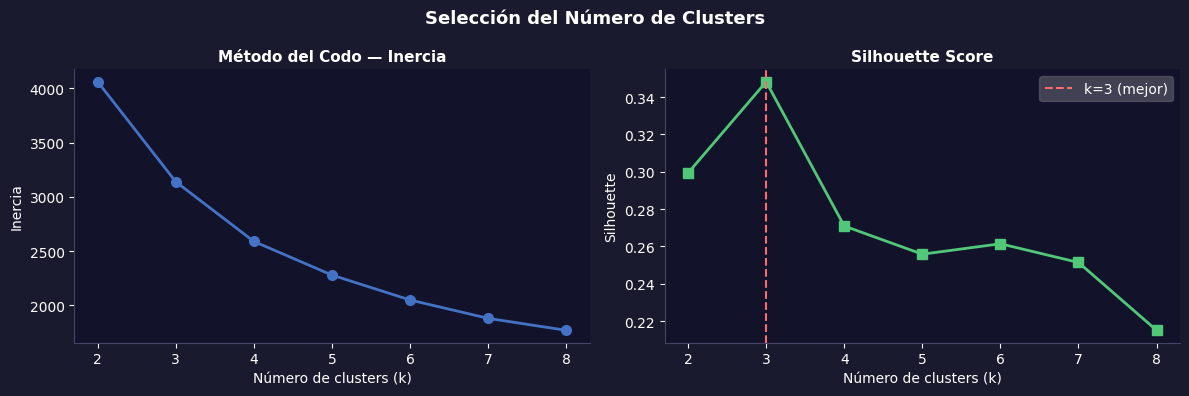

Mejor k según Silhouette: 3
  k=2  silhouette=0.2994
  k=3  silhouette=0.3482
  k=4  silhouette=0.2710
  k=5  silhouette=0.2559
  k=6  silhouette=0.2615
  k=7  silhouette=0.2514
  k=8  silhouette=0.2151


In [ ]:
# Paso 4 — Método del codo y Silhouette score
inercias = []
silhouettes = []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1a1a2e')

for ax in axes:
    ax.set_facecolor('#12122a')
    ax.tick_params(colors='white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#444466')

axes[0].plot(ks, inercias, 'o-', color='#4472C4', linewidth=2, markersize=7)
axes[0].set_title('Método del Codo — Inercia', color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)', color='white')
axes[0].set_ylabel('Inercia', color='white')

axes[1].plot(ks, silhouettes, 's-', color='#50C878', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score', color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)', color='white')
axes[1].set_ylabel('Silhouette', color='white')

mejor_k = ks[np.argmax(silhouettes)]
axes[1].axvline(mejor_k, color='#FF6B6B', linestyle='--', linewidth=1.5, label=f'k={mejor_k} (mejor)')
axes[1].legend(framealpha=0.2, labelcolor='white')

fig.suptitle('Selección del Número de Clusters', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/p03_01_elbow.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
plt.close()

print(f'Mejor k según Silhouette: {mejor_k}')
for k, s in zip(ks, silhouettes):
    print(f'  k={k}  silhouette={s:.4f}')

## Paso 5 — Aplicar KMeans y asignar clusters

In [ ]:
# Paso 5 — KMeans con k=5 (5 perfiles tácticos naturales en fútbol)
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

medias_rel = df.groupby('cluster')[FEAT_NORM].mean()

# Normalizar medias 0-1 para scoring por perfil
medias_norm = (medias_rel - medias_rel.min()) / (medias_rel.max() - medias_rel.min() + 1e-9)

# Score compuesto por perfil táctico
scores = pd.DataFrame(index=range(K))
scores['portero']    = ((medias_rel['tiros_p100'] < 0.5).astype(float) * 3 +
                        (medias_rel['presiones_p100'] < 1.0).astype(float) * 2)
scores['delantero']  = (medias_norm['goles_p100'] * 2.0 +
                        medias_norm['tiros_p100'] * 1.5 +
                        medias_norm['xg_total_p100'] * 1.5)
scores['defensor']   = (medias_norm['despejes_p100'] * 2.0 +
                        medias_norm['intercepciones_p100'] * 1.5 -
                        medias_norm['tiros_p100'] * 1.0)
scores['extremo']    = (medias_norm['regates_p100'] * 2.0 +
                        medias_norm['tiros_p100'] * 1.0 -
                        medias_norm['despejes_p100'] * 1.0)
scores['mediocampo'] = (medias_norm['pases_p100'] * 1.5 +
                        medias_norm['presiones_p100'] * 1.5 +
                        medias_norm['recuperaciones_p100'] * 1.0 -
                        medias_norm['tiros_p100'] * 0.5)

# Asignación greedy: cluster con mayor score a cada perfil, sin repetir
perfiles_ordenados = ['portero', 'delantero', 'defensor', 'extremo', 'mediocampo']
nombres_finales    = ['Portero', 'Delantero / Finalizador', 'Defensor Central',
                      'Extremo / Dribblador', 'Mediocampista']

nombres_cluster = {}
clusters_disponibles = list(range(K))
for perfil, nombre in zip(perfiles_ordenados, nombres_finales):
    mejor = scores.loc[clusters_disponibles, perfil].idxmax()
    nombres_cluster[mejor] = nombre
    clusters_disponibles.remove(mejor)

df['perfil'] = df['cluster'].map(nombres_cluster)

print('Medias por cluster:')
print(df.groupby('perfil')[FEATURES].mean().round(1).to_string())
print()
print('Distribución de jugadores por perfil:')
print(df['perfil'].value_counts().to_string())

Medias por cluster:
                         pases  conducciones  presiones  duelos  intercepciones  recuperaciones  despejes  regates  tiros  goles  xg_total
perfil                                                                                                                                    
Defensor Central         740.7         466.7      182.9    73.2            29.8            66.2     127.7      6.9   10.1    0.9       1.0
Delantero / Finalizador  364.9         330.6      202.5    88.2             5.2            47.2      11.7     28.8   37.8    5.4       5.2
Extremo / Dribblador     616.9         610.4      255.8    53.3            12.1            86.1      10.4     58.1   31.3    3.3       2.8
Mediocampista            969.4         706.5      293.3    71.2            24.2            96.6      46.0     24.6   15.1    0.9       1.1
Portero                  533.3         218.2        2.4     0.1             0.0            86.8       0.9      0.3    0.0    0.0       0.0

Distri

## Paso 6 — Visualización PCA: mapa de jugadores

Varianza explicada — PC1: 38.2%  PC2: 20.1%  Total: 58.2%


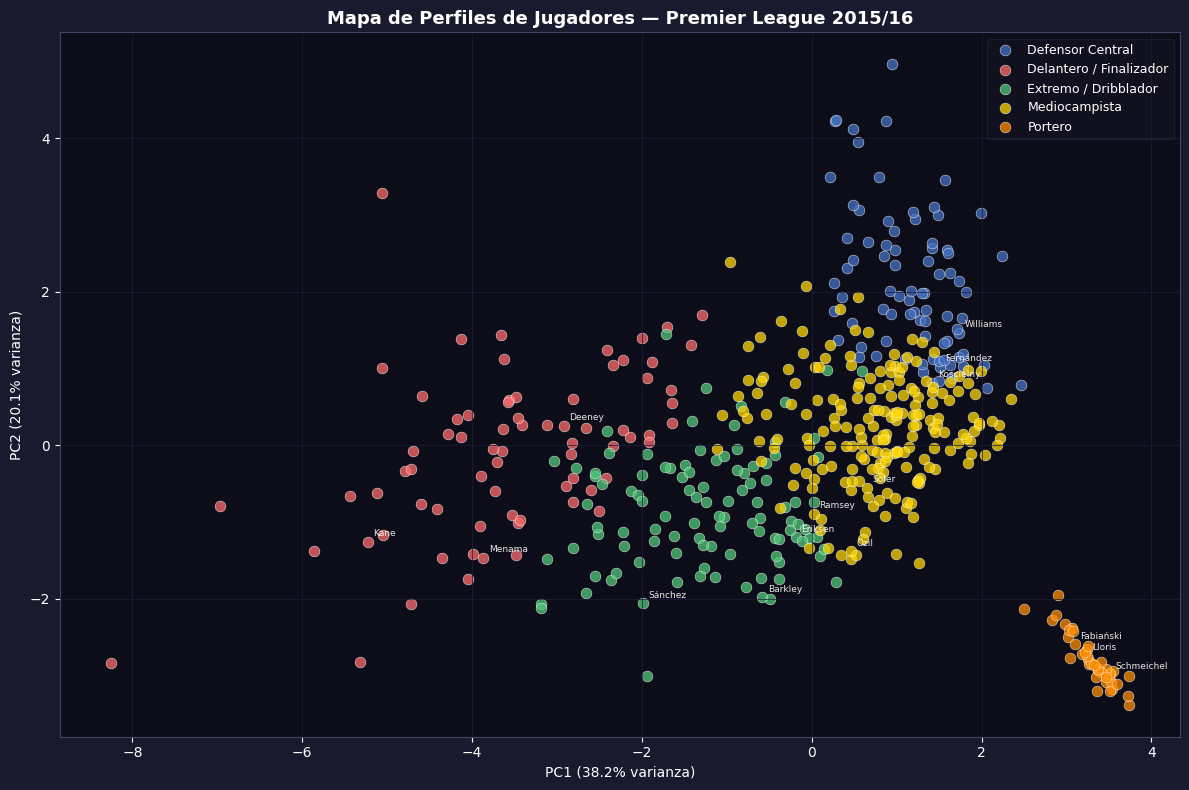

Gráfico guardado.


In [ ]:
# Paso 6 — Reducir a 2D con PCA y graficar clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

varianza = pca.explained_variance_ratio_
print(f'Varianza explicada — PC1: {varianza[0]:.1%}  PC2: {varianza[1]:.1%}  Total: {sum(varianza):.1%}')

COLORES = ['#4472C4', '#FF6B6B', '#50C878', '#FFD700', '#FF8C00']
perfiles_unicos = sorted(df['perfil'].unique())
color_map = {p: COLORES[i % len(COLORES)] for i, p in enumerate(perfiles_unicos)}

plt.close('all')
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#0d0d1a')

for perfil in perfiles_unicos:
    mask = df['perfil'] == perfil
    ax.scatter(
        df.loc[mask, 'pca_x'], df.loc[mask, 'pca_y'],
        c=color_map[perfil], label=perfil,
        s=60, alpha=0.75, edgecolors='white', linewidths=0.4
    )

# Etiquetar los 3 mejores de cada cluster (por total_acciones)
for perfil in perfiles_unicos:
    subset = df[df['perfil'] == perfil].nlargest(3, 'total_acciones')
    for _, row in subset.iterrows():
        nombre = row['player'].split()[-1]  # sólo apellido
        ax.annotate(nombre, (row['pca_x'], row['pca_y']),
                    fontsize=6.5, color='white', alpha=0.9,
                    xytext=(4, 4), textcoords='offset points')

legend = ax.legend(framealpha=0.25, labelcolor='white', fontsize=9,
                   loc='upper right', facecolor='#1a1a2e', edgecolor='#444466')

ax.set_title('Mapa de Perfiles de Jugadores — Premier League 2015/16',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({varianza[0]:.1%} varianza)', color='white')
ax.set_ylabel(f'PC2 ({varianza[1]:.1%} varianza)', color='white')
ax.tick_params(colors='white')
ax.spines[['top','right','left','bottom']].set_color('#444466')
ax.grid(color='#1e1e3a', linewidth=0.5)

plt.tight_layout()
plt.savefig('graficos/p03_02_pca_clusters.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()
print('Gráfico guardado.')

## Paso 7 — Radar Chart de perfil medio por cluster

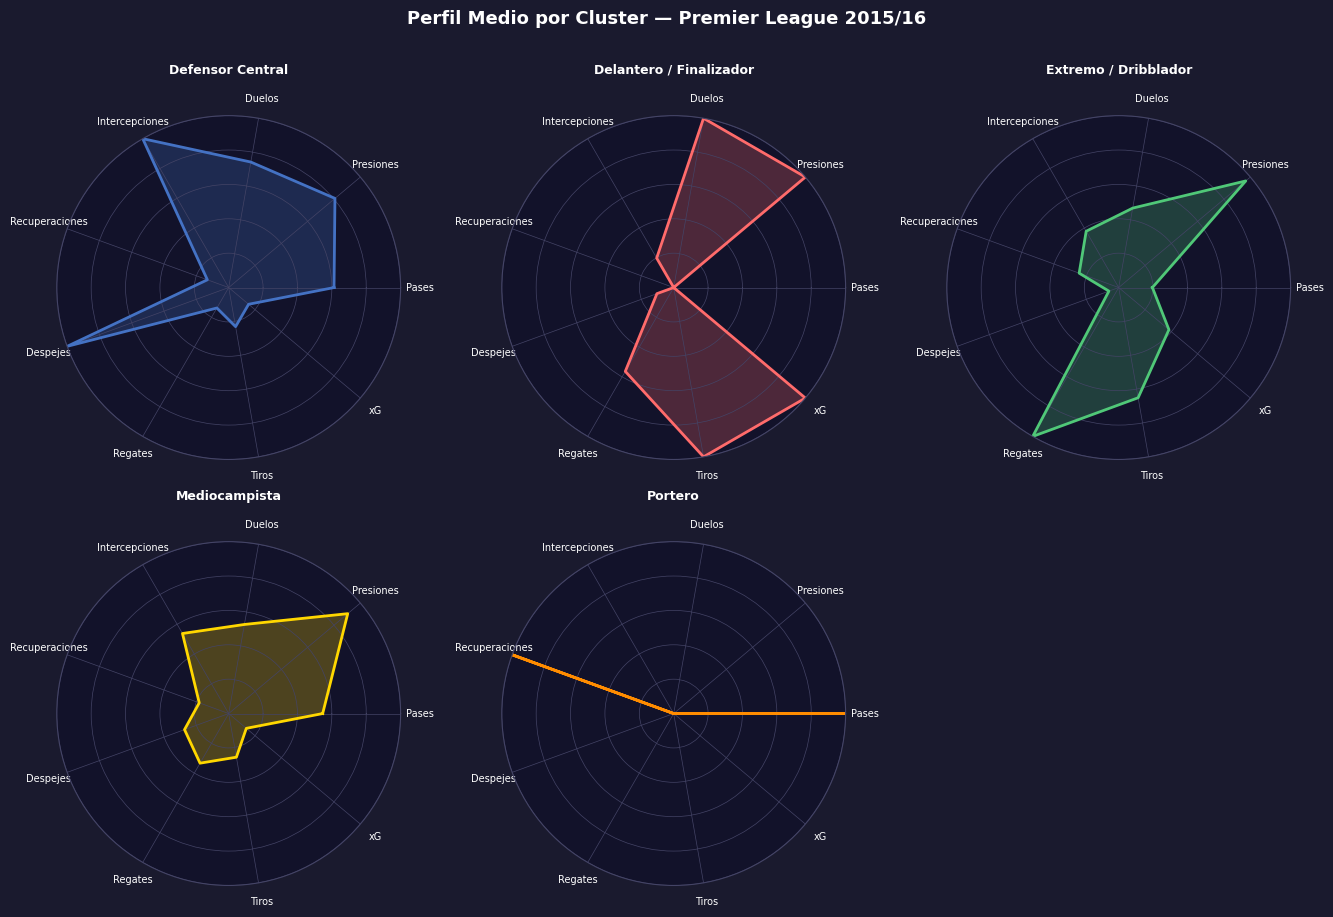

Radar charts guardados.


In [ ]:
# Paso 7 — Radar chart con perfil promedio de cada cluster
RADAR_FEATURES = [
    'pases_p100', 'presiones_p100', 'duelos_p100',
    'intercepciones_p100', 'recuperaciones_p100',
    'despejes_p100', 'regates_p100',
    'tiros_p100', 'xg_total_p100'
]
RADAR_LABELS = [
    'Pases', 'Presiones', 'Duelos',
    'Intercepciones', 'Recuperaciones',
    'Despejes', 'Regates',
    'Tiros', 'xG'
]

medias = df.groupby('perfil')[RADAR_FEATURES].mean()

# Normalizar 0-1 para el radar
radar_norm = (medias - medias.min()) / (medias.max() - medias.min() + 1e-9)

def radar_chart(ax, valores, labels, color, titulo):
    N = len(labels)
    angulos = [n / float(N) * 2 * math.pi for n in range(N)]
    angulos += angulos[:1]
    valores_plot = list(valores) + [valores[0]]

    ax.set_facecolor('#12122a')
    ax.plot(angulos, valores_plot, color=color, linewidth=2)
    ax.fill(angulos, valores_plot, alpha=0.25, color=color)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels, color='white', fontsize=7)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.spines['polar'].set_color('#444466')
    ax.grid(color='#444466', linewidth=0.5)
    ax.set_title(titulo, color='white', fontsize=9, fontweight='bold', pad=15)

perfiles_plot = radar_norm.index.tolist()
n_perfiles = len(perfiles_plot)
cols = 3
rows = math.ceil(n_perfiles / cols)

plt.close('all')
fig = plt.figure(figsize=(cols * 4.5, rows * 4.5))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Perfil Medio por Cluster — Premier League 2015/16',
             color='white', fontsize=13, fontweight='bold', y=1.01)

for i, perfil in enumerate(perfiles_plot):
    ax = fig.add_subplot(rows, cols, i + 1, polar=True)
    vals = radar_norm.loc[perfil, RADAR_FEATURES].values
    radar_chart(ax, vals, RADAR_LABELS, COLORES[i % len(COLORES)], perfil)

plt.tight_layout()
plt.savefig('graficos/p03_03_radar_clusters.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()
print('Radar charts guardados.')

## Paso 8 — Top jugadores por perfil


DEFENSOR CENTRAL
                    player            team  pases  tiros  goles  presiones  intercepciones  total_acciones
           Ashley Williams    Swansea City   1884   16.0    2.0        269              69            5834
        Federico Fernández    Swansea City   1745   17.0    1.0        312              49            5442
         Laurent Koscielny         Arsenal   1671   20.0    4.0        269              61            5170
   Nicolás Hernán Otamendi Manchester City   1561   28.0    1.0        358              83            5116
José Miguel da Rocha Fonte     Southampton   1642   24.0    2.0        274              58            4980

DELANTERO / FINALIZADOR
              player              team  pases  tiros  goles  presiones  intercepciones  total_acciones
         Troy Deeney           Watford   1302   94.0   13.0        609               8            6121
          Harry Kane Tottenham Hotspur   1005  158.0   25.0        491              12            5746
Romelu

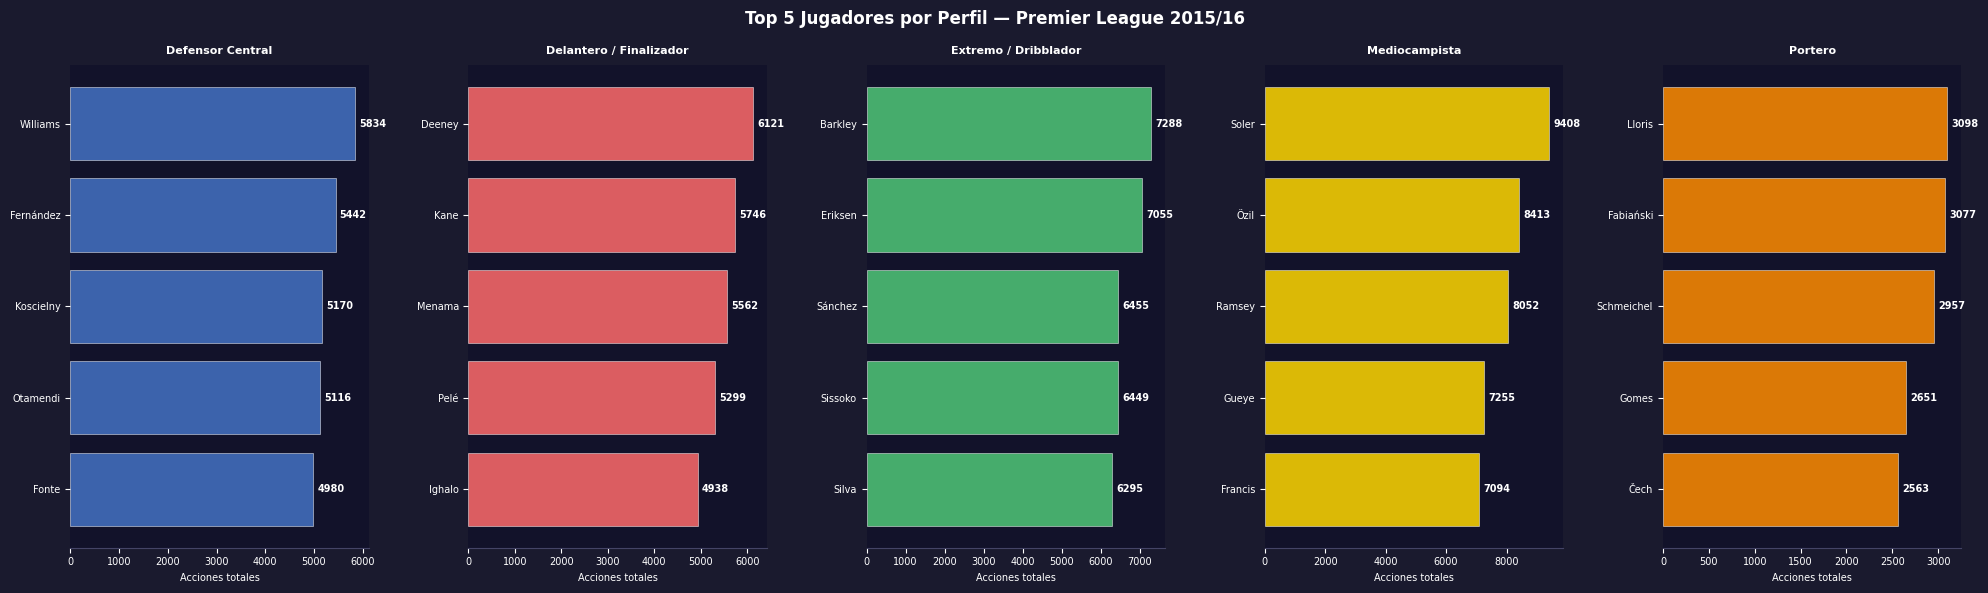


Gráfico guardado.


In [ ]:
# Paso 8 — Top 5 jugadores por perfil (por total_acciones como proxy de minutos)
print('=' * 60)
for perfil in perfiles_unicos:
    subset = df[df['perfil'] == perfil].nlargest(5, 'total_acciones')
    print(f'\n{perfil.upper()}')
    print(subset[['player','team','pases','tiros','goles','presiones','intercepciones','total_acciones']]
          .to_string(index=False))

plt.close('all')
fig, axes = plt.subplots(1, len(perfiles_unicos), figsize=(4 * len(perfiles_unicos), 6))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Top 5 Jugadores por Perfil — Premier League 2015/16',
             color='white', fontsize=12, fontweight='bold')

if len(perfiles_unicos) == 1:
    axes = [axes]

for ax, perfil, color in zip(axes, perfiles_unicos, COLORES):
    ax.set_facecolor('#12122a')
    subset = df[df['perfil'] == perfil].nlargest(5, 'total_acciones')
    nombres = [p.split()[-1] for p in subset['player']]
    valores = subset['total_acciones'].values
    bars = ax.barh(nombres[::-1], valores[::-1], color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.4)
    ax.bar_label(bars, padding=3, color='white', fontsize=7, fontweight='bold')
    ax.set_title(perfil, color='white', fontsize=8, fontweight='bold', pad=8)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[['top','right','left']].set_visible(False)
    ax.spines['bottom'].set_color('#444466')
    ax.set_xlabel('Acciones totales', color='white', fontsize=7)

plt.tight_layout()
plt.savefig('graficos/p03_04_top_jugadores_perfil.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()
print('\nGráfico guardado.')

## Paso 9 — Comparador de jugadores: radar individual

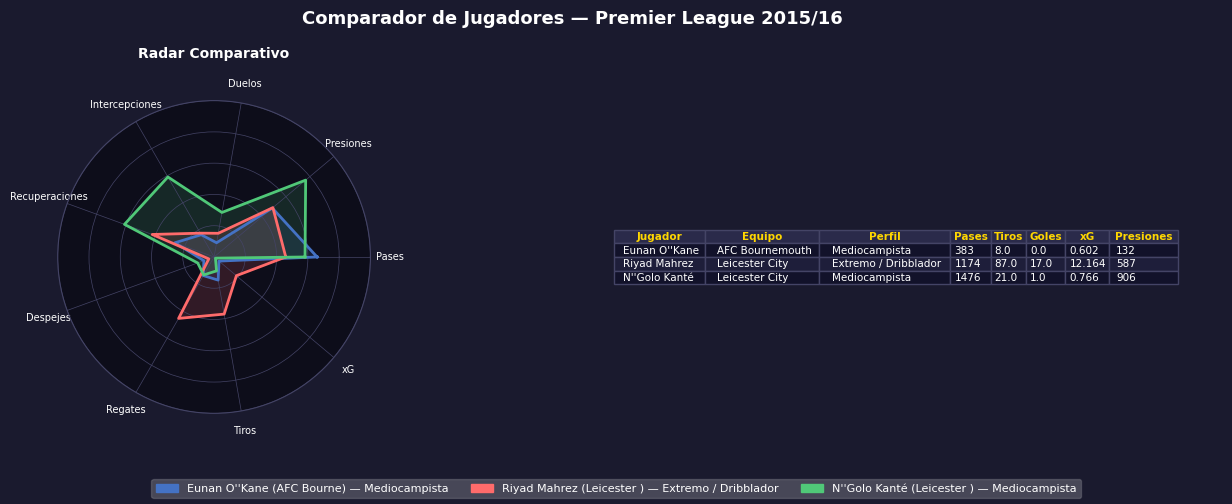

Comparador guardado.


In [ ]:
# Paso 9 — Radar chart para comparar jugadores específicos
# Modifica esta lista para comparar los jugadores que quieras
JUGADORES_COMPARAR = [
    'Harry Kane',
    'Riyad Mahrez',
    'N\'Golo Kanté',
]

# Busqueda flexible: coincidencia parcial
def buscar_jugador(nombre, df):
    mask = df['player'].str.contains(nombre.split()[-1], case=False, na=False)
    if mask.sum() == 0:
        # intentar con primer nombre
        mask = df['player'].str.contains(nombre.split()[0], case=False, na=False)
    return df[mask].iloc[0] if mask.sum() > 0 else None

# Normalizar por máximo global en el dataset
maximos = df[RADAR_FEATURES].max()

plt.close('all')
fig = plt.figure(figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Comparador de Jugadores — Premier League 2015/16',
             color='white', fontsize=13, fontweight='bold')

encontrados = []
for nombre in JUGADORES_COMPARAR:
    row = buscar_jugador(nombre, df)
    if row is not None:
        encontrados.append(row)
    else:
        print(f'  ⚠️  Jugador no encontrado: {nombre}')

if not encontrados:
    print('Ningún jugador encontrado. Revisa los nombres.')
else:
    N = len(RADAR_LABELS)
    angulos = [n / float(N) * 2 * math.pi for n in range(N)]
    angulos += angulos[:1]

    ax = fig.add_subplot(1, 2, 1, polar=True)
    ax.set_facecolor('#0d0d1a')

    COMP_COLORES = ['#4472C4', '#FF6B6B', '#50C878', '#FFD700']
    leyenda_items = []

    for i, row in enumerate(encontrados):
        vals_raw = row[RADAR_FEATURES].values.astype(float)
        vals_norm = np.clip(vals_raw / (maximos.values + 1e-9), 0, 1)
        vals_plot = list(vals_norm) + [vals_norm[0]]
        color = COMP_COLORES[i % len(COMP_COLORES)]
        ax.plot(angulos, vals_plot, color=color, linewidth=2, label=row['player'])
        ax.fill(angulos, vals_plot, alpha=0.15, color=color)
        leyenda_items.append(mpatches.Patch(color=color, label=f"{row['player']} ({row['team'][:10]}) — {row['perfil']}"))

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(RADAR_LABELS, color='white', fontsize=7)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.spines['polar'].set_color('#444466')
    ax.grid(color='#444466', linewidth=0.5)
    ax.set_title('Radar Comparativo', color='white', fontsize=10, fontweight='bold', pad=15)

    # Tabla de stats
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.set_facecolor('#12122a')
    ax2.axis('off')

    cols_tabla = ['player', 'team', 'perfil', 'pases', 'tiros', 'goles', 'xg_total', 'presiones']
    filas = [[str(row[c]) for c in cols_tabla] for row in encontrados]
    headers = ['Jugador', 'Equipo', 'Perfil', 'Pases', 'Tiros', 'Goles', 'xG', 'Presiones']

    tabla = ax2.table(
        cellText=filas, colLabels=headers,
        loc='center', cellLoc='left'
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(7.5)
    tabla.auto_set_column_width(range(len(headers)))

    for (row_idx, col_idx), cell in tabla.get_celld().items():
        cell.set_facecolor('#1e1e3a' if row_idx % 2 == 0 else '#12122a')
        cell.set_text_props(color='white')
        cell.set_edgecolor('#444466')
        if row_idx == 0:
            cell.set_facecolor('#2a2a4a')
            cell.set_text_props(color='#FFD700', fontweight='bold')

    fig.legend(handles=leyenda_items, loc='lower center', framealpha=0.2,
               labelcolor='white', fontsize=8, ncol=len(encontrados))

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig('graficos/p03_05_comparador.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()
print('Comparador guardado.')

## Paso 10 — Análisis: ¿qué equipo tiene más diversidad de perfiles?

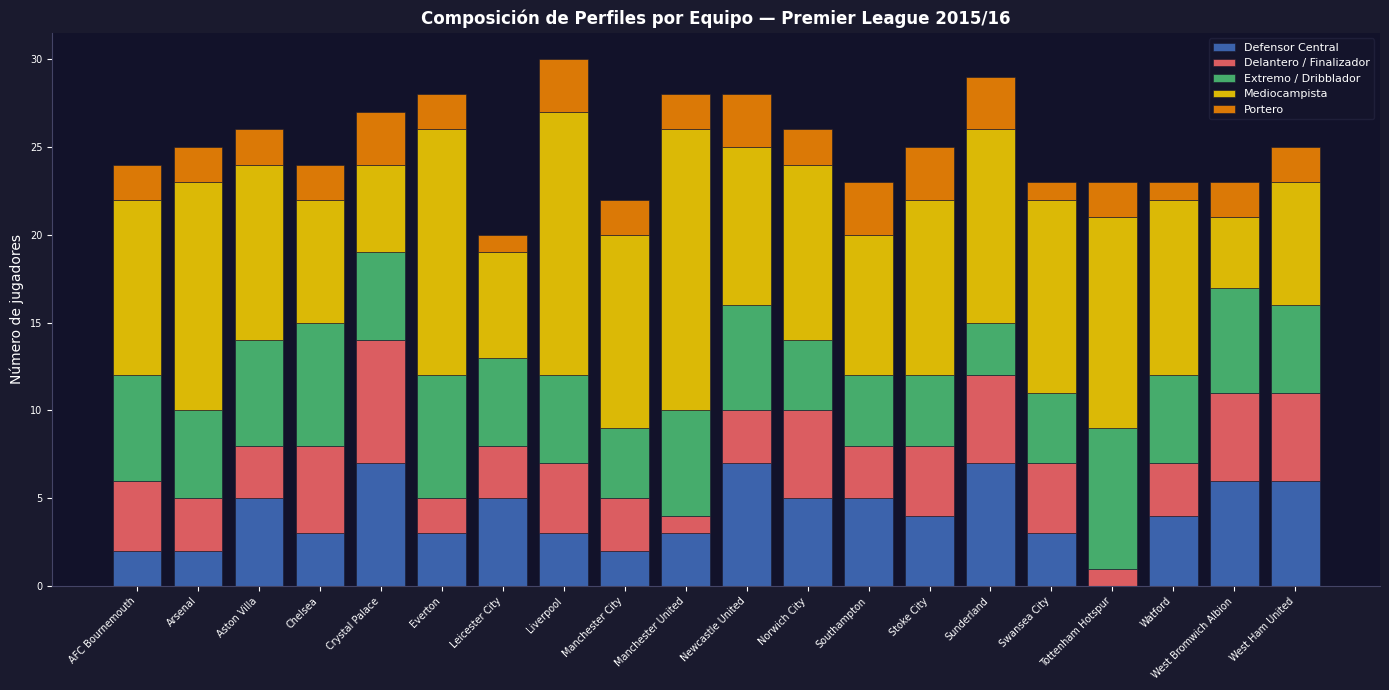


Distribución por equipo:
perfil                Defensor Central  Delantero / Finalizador  Extremo / Dribblador  Mediocampista  Portero
team                                                                                                         
AFC Bournemouth                      2                        4                     6             10        2
Arsenal                              2                        3                     5             13        2
Aston Villa                          5                        3                     6             10        2
Chelsea                              3                        5                     7              7        2
Crystal Palace                       7                        7                     5              5        3
Everton                              3                        2                     7             14        2
Leicester City                       5                        3                     5         

In [ ]:
# Paso 10 — Distribución de perfiles por equipo
dist_equipos = df.groupby(['team', 'perfil']).size().unstack(fill_value=0)

plt.close('all')
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#12122a')

bottom = np.zeros(len(dist_equipos))
for i, perfil in enumerate(dist_equipos.columns):
    vals = dist_equipos[perfil].values
    ax.bar(dist_equipos.index, vals, bottom=bottom,
           color=COLORES[i % len(COLORES)], label=perfil,
           alpha=0.85, edgecolor='#1a1a2e', linewidth=0.5)
    bottom += vals

ax.set_title('Composición de Perfiles por Equipo — Premier League 2015/16',
             color='white', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de jugadores', color='white')
ax.tick_params(colors='white', labelsize=7)
ax.set_xticklabels(dist_equipos.index, rotation=45, ha='right', color='white', fontsize=7)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#444466')
ax.legend(framealpha=0.25, labelcolor='white', fontsize=8,
          facecolor='#1a1a2e', edgecolor='#444466', loc='upper right')

plt.tight_layout()
plt.savefig('graficos/p03_06_perfiles_por_equipo.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

print('\nDistribución por equipo:')
print(dist_equipos.to_string())

In [ ]:
# Cerrar conexión
conn.close()
print('Análisis completado. Gráficos en la carpeta graficos/')
print('\nResumen de archivos generados:')
for f in sorted(os.listdir('graficos')):
    print(f'  graficos/{f}')

Análisis completado. Gráficos en la carpeta graficos/

Resumen de archivos generados:
  graficos/p03_01_elbow.png
  graficos/p03_02_pca_clusters.png
  graficos/p03_03_radar_clusters.png
  graficos/p03_04_top_jugadores_perfil.png
  graficos/p03_05_comparador.png
  graficos/p03_06_perfiles_por_equipo.png
